In [13]:
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn import datasets 
from sklearn.model_selection import train_test_split 
from sklearn.naive_bayes import GaussianNB

In [12]:
import sys

!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.4 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.4 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.4 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.4 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.4 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.4 MB 736.2 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.4 MB 752.2 kB/s eta 0:00:10
   ----------- ---------------------------- 2.4/8.4 MB 1.1 MB/s eta 0:00:06
   ------------- -------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Tải dữ liệu Iris

In [14]:
# Downloading the iris dataset 
iris = datasets.load_iris() 
class_names = iris.target_names 
# Convert to pandas format for easier processing 
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names) 
iris_df['target'] = iris.target 
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Train and Test

In [ ]:
# train_test_split : chia dữ liệu thành 4 phần
X_train, X_test, y_train, y_test = train_test_split(
    iris_df[['sepal length (cm)', 'sepal width (cm)',
             'petal length (cm)', 'petal width (cm)']],
    iris_df['target'],
    test_size=0.2, # 20% dữ liệu test
    random_state=2021
)

## Huấn luyện Model Naive Bayes

In [ ]:
# Import Naive Bayes
NB = GaussianNB()

# Train Naive Bayes Model
NB.fit(X_train, y_train) # Cho model học từ dữ liệu
print("Training accuracy: {:.2f}".format(NB.score(X_train, y_train)))

# Evaluate Model on test set
y_predict = NB.predict(X_test) # Bước dự đoán
print("Testing accuracy NB: {:.2f}".format(NB.score(X_test, y_test)))

Training accuracy: 0.97
Testing accuracy NB: 0.93


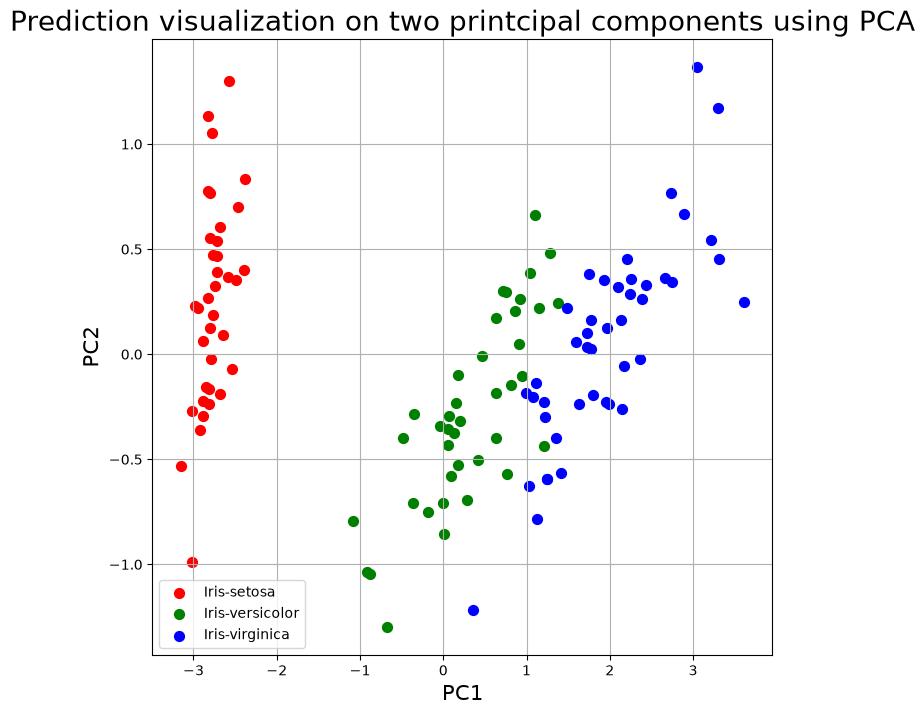

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principalComponent = pca.fit_transform(X_train) # học cấu trúc dữ liệu

principalDf = pd.DataFrame(data=principalComponent, columns=['PC1', 'PC2'])
finalDf = pd.concat([principalDf, y_train.reset_index(drop=True)], axis=1)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('PC1', fontsize=15)
ax.set_ylabel('PC2', fontsize=15)
ax.set_title('Prediction visualization on two printcipal components using PCA', fontsize = 20)

targets = [0, 1, 2]
targets_2_desc = {0: 'Iris-setosa',1: 'Iris-versicolor', 2:'Iris-virginica'}
colors = ['r','g','b']
for target, color in zip(targets, colors):
    indicesTokeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesTokeep, 'PC1'],
               finalDf.loc[indicesTokeep,'PC2'],
               c=color,
               s=50,
               label=targets_2_desc[target])

ax.legend()
ax.grid()
